<a href="https://colab.research.google.com/github/alexnascimento2121/Python_Tratamento_Imagem/blob/main/AlgoritmoCNN_Densenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Origem dos dados
O modelo foi desenvolvido utilizando o conjunto de dados RSNA Pneumonia Detection Challenge, disponibilizado pelo Kaggle. O dataset é composto por radiografias de tórax em formato DICOM e seus respectivos rótulos, indicando a presença ou ausência de pneumonia.Foi utilizado um subconjunto do dataset contendo aproximadamente 26.684 imagens.
# Divisão dos dados
Os dados foram divididos utilizando a função train_test_split da biblioteca Scikit-Learn.
Distribuição utilizada:
Conjunto	Quantidade
Treinamento	21.347 imagens (80%)
Validação	5.337 imagens (20%)
# Pré-processamento
Antes do treinamento, as imagens passaram pelas seguintes etapas de Pré-Processamento:
leitura dos arquivos DICOM;
extração da matriz de pixels;
normalização dos valores dos pixels para o intervalo entre 0 e 1;
redimensionamento para 224 × 224 pixels;
conversão das imagens para três canais (RGB), permitindo compatibilidade com a arquitetura DenseNet121;
construção do pipeline utilizando tf.data.Dataset, com processamento em lotes (batch) e pré-carregamento (prefetch) para otimizar o treinamento.

# Arquitetura do Modelo
O modelo foi baseado na arquitetura DenseNet121,uma Rede Neural Convolucional (CNN) composta por 121 camadas, utilizando aprendizado por transferência (Transfer Learning) que permite aproveitar o conhecimento adquirido por uma rede neural treinada previamente em um grande conjunto de imagens, reduzindo o tempo de treinamento e melhorando a capacidade de generalização, neste caso, a DenseNet121  foi pré-treinada no ImageNet, um banco de dados de imagem gigantesco. Devido a ser treinada no ImageNet foi necessário aplicar a
remoção da camada de classificação original (include_top=False), para que não trouxesse a camada responsavel pela classificação em categorias(carros,brinquedosanimais) apenas as camadas inferiores responsaveis pela extração das caracteristicas;Outra importante medida foi o congelamento das camadas convolucionais da DenseNet, para que os pesos aprendidos durante o treinamento no ImageNet não fossem modificados; A camada GlobalAveragePooling2D permite transformar mapas de caracteristicas resultante da DenseNet em um vetor que simplifica o treinamento;Após o Vetor foi introduzido a camada de saída com ativação sigmoide para classificação binária onde a imagem só pode ser do tipo Pneumonia ou normal, e isso é representado por uma probabilidade entre 0 e 1;
Parâmetros de treinamento:
Otimizador: Adam -> algoritmo responsável por atualizar os pesos da rede neural
Taxa de aprendizado: 0,0001 -> o tamanho do passo dado pelo otimizador durante a atualização dos pesos.
Função de perda: Binary Crossentropy ->responsável por medir o erro entre a resposta prevista pelo modelo e a resposta correta.
Métricas monitoradas durante o treinamento:
Accuracy
AUC
# Treinamento
O treinamento foi configurado para 50 épocas.
Durante o treinamento foram monitoradas as métricas de treinamento e validação para acompanhar a evolução do modelo.

Ao final do treinamento, observou-se que as métricas de treinamento e validação permaneceram próximas, indicando bom comportamento durante essa etapa.

# Avaliação
As métricas registradas no notebook foram:
Métrica	Resultado
Acurácia de treinamento	81,9%
Acurácia de validação	81,8%
AUC de validação	83,83%
Loss de validação	0,3968

Os resultados indicam que o modelo conseguiu aprender padrões relevantes das imagens durante o treinamento, apresentando desempenho semelhante entre os conjuntos de treinamento e validação.
Na etapa de avaliação do modelo, utilizando o conjunto definido para validação no notebook, foram obtidos os seguintes resultados:
Acurácia (Accuracy)	81,77%
AUC	83,83%
Loss	0,3968

O modelo baseado na arquitetura DenseNet121 apresentou desempenho consistente durante o treinamento e a validação, alcançando aproximadamente 81,8% de acurácia e 83,8% de AUC. Isso significa que cerca de 82 em cada 100 imagens foram classificadas corretamente e que modelo possui boa capacidade de diferenciar radiografias com pneumonia das radiografias normais.


## Instalação do TensorFlow e Bibliotecas Auxiliares

In [ ]:
!pip install -q tensorflow pandas numpy matplotlib scikit-learn pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.9 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.applications import DenseNet121
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model
from keras.optimizers import Adam

# Carregar os dados de CSV aproveitando dados que vem do Kaggle

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move(
    "kaggle.json",
    "/root/.kaggle/kaggle.json"
)

os.chmod(
    "/root/.kaggle/kaggle.json",
    600
)

In [ ]:
!kaggle competitions download \
    -c rsna-pneumonia-detection-challenge

100% 3.66G/3.66G [00:31<00:00, 124MB/s] 



In [ ]:
import zipfile

with zipfile.ZipFile(
    "rsna-pneumonia-detection-challenge.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("/content/rsna")

In [ ]:
import os

for arquivo in os.listdir("/content/rsna"):
    print(arquivo)

stage_2_sample_submission.csv
stage_2_test_images
stage_2_train_images
stage_2_detailed_class_info.csv
stage_2_train_labels.csv
GCP Credits Request Link - RSNA.txt


In [ ]:
labels = pd.read_csv(
    "/content/rsna/stage_2_train_labels.csv"
)

print(labels.shape)

labels.head()

(30227, 6)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


Cria dataset de classificação e agrupa os pacientes por Target

In [ ]:
classification_df = (
    labels
    .groupby("patientId")["Target"]
    .max()
    .reset_index()
)

classification_df.head()

,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,000924cf-0f8d-42bd-9158-1af53881a557,0
2,000db696-cf54-4385-b10b-6b16fbb3f985,1
3,000fe35a-2649-43d4-b027-e67796d412e0,1
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1


Verifica o Caminho das imagens DICOM e Configurar Redimensionamento

In [ ]:
IMAGE_DIR = "/content/rsna/stage_2_train_images"

IMG_SIZE = 224

MAX_IMAGES = 26684

## Função para ler DICOM

In [ ]:
def load_dicom(path):

    dicom = pydicom.dcmread(path)

    image = dicom.pixel_array.astype(
        np.float32
    )

    image = (
        image - image.min()
    ) / (
        image.max() - image.min() + 1e-8
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = np.stack(
        [image, image, image],
        axis=-1
    )

    return image

In [ ]:
# Leitura DICOM
import pydicom

# Processamento de imagem
import cv2

# Operações matemáticas
import numpy as np

# Pasta origem
DICOM_DIR = "/content/rsna/stage_2_train_images"

# Pasta destino
JPG_DIR = f"{BASE_DIR}/images"

# Lista todas as imagens
arquivos = sorted(
    os.listdir(DICOM_DIR)
)

# Quantidade por lote
BATCH_SIZE = 1000

# Processa em lotes
for inicio in range(
    0,
    len(arquivos),
    BATCH_SIZE
):

    fim = min(
        inicio + BATCH_SIZE,
        len(arquivos)
    )

    print(
        f"Processando lote {inicio} - {fim}"
    )

    lote = arquivos[inicio:fim]

    for arquivo in lote:

        nome_jpg = arquivo.replace(
            ".dcm",
            ".jpg"
        )

        caminho_jpg = os.path.join(
            JPG_DIR,
            nome_jpg
        )

        # Evita reprocessamento
        if os.path.exists(caminho_jpg):
            continue

        try:

            ds = pydicom.dcmread(
                os.path.join(
                    DICOM_DIR,
                    arquivo
                )
            )

            imagem = ds.pixel_array

            imagem = (
                imagem - imagem.min()
            ) / (
                imagem.max() - imagem.min()
            )

            imagem = (
                imagem * 255
            ).astype(np.uint8)

            cv2.imwrite(
                caminho_jpg,
                imagem
            )

        except Exception as erro:

            print(
                f"Erro {arquivo}: {erro}"
            )

    print(
        f"Lote finalizado {fim}"
    )

NameError: name 'BASE_DIR' is not defined

# Criar lista de caminhos

In [ ]:
paths = []
targets = []

for _, row in classification_df.head(MAX_IMAGES).iterrows():

    patient_id = row["patientId"]

    path = os.path.join(
        IMAGE_DIR,
        patient_id + ".dcm"
    )

    if os.path.exists(path):

        paths.append(path)

        targets.append(
            np.int32(row["Target"])
        )

print("Imagens:", len(paths))

Imagens: 26684


# Separar treino e validação

In [ ]:
train_paths, val_paths, train_targets, val_targets = train_test_split(
    paths,
    targets,
    test_size=0.2,
    random_state=42,
    stratify=targets
)

# Dataset por lotes

In [ ]:
def process_image(path, label):

    path = path.decode("utf-8")

    image = load_dicom(path)

    image = image.astype(np.float32)

    return image, np.int32(label)

In [ ]:
def create_dataset(paths, labels, batch_size=8):

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    def load_wrapper(path, label):

        image, label = tf.numpy_function(
            process_image,
            [path, label],
            [tf.float32, tf.int32]
        )

        # Define explicitamente o formato esperado
        image.set_shape((224, 224, 3))

        label.set_shape(())

        return image, label

    dataset = dataset.map(
        load_wrapper,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

# Criar datasets

In [ ]:
train_dataset = create_dataset(
    train_paths,
    train_targets,
    batch_size=8
)

val_dataset = create_dataset(
    val_paths,
    val_targets,
    batch_size=8
)

# GPU e Lote do Dataset

In [ ]:
print(
    tf.config.list_physical_devices(
        'GPU'
    )
)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
for images, labels in train_dataset.take(1):

    print("Shape imagens:", images.shape)
    print("Shape labels:", labels.shape)

    break

Shape imagens: (8, 224, 224, 3)
Shape labels: (8,)


# Criar DenseNet121

In [ ]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Congelar camadas

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

# Classificador

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

# Compilar

In [ ]:
model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC()
    ]
)

# Treinando Modelo

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50
)

Epoch 1/50
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 349s 120ms/step - accuracy: 0.7849 - auc: 0.7616 - loss: 0.4571 - val_accuracy: 0.7928 - val_auc: 0.7943 - val_loss: 0.4356
Epoch 2/50
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 296s 111ms/step - accuracy: 0.7981 - auc: 0.7992 - loss: 0.4292 - val_accuracy: 0.7969 - val_auc: 0.8072 - val_loss: 0.4249
Epoch 3/50
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 321s 110ms/step - accuracy: 0.8036 - auc: 0.8090 - loss: 0.4208 - val_accuracy: 0.8016 - val_auc: 0.8144 - val_loss: 0.4186
Epoch 4/50
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 296s 111ms/step - accuracy: 0.8070 - auc: 0.8153 - loss: 0.4155 - val_accuracy: 0.8064 - val_auc: 0.8191 - val_loss: 0.4143
Epoch 5/50
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 315s 108ms/step - accuracy: 0.8079 - auc: 0.8197 - loss: 0.4116 - val_accuracy: 0.8076 - val_auc: 0.8225 - val_loss: 0.4113
Epoch 6/50
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 295s 98ms/step - accuracy: 0.8094 - auc: 0.8229 - loss: 0.4087 - val_accuracy: 0.8083 - val_auc: 0.8251 - val_loss: 0.4089
Epoch

# Preparar Imagens para Visualizar

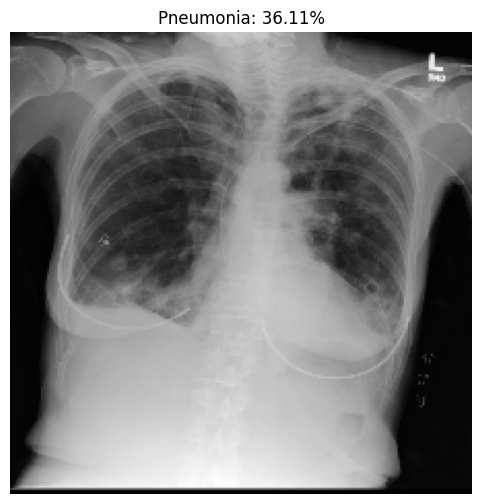

In [ ]:
for images_batch, labels_batch in val_dataset.take(1):

    sample = images_batch[0]

    pred = model.predict(
        tf.expand_dims(sample, axis=0),
        verbose=0
    )[0][0]

    plt.figure(figsize=(6,6))

    plt.imshow(
        sample[:,:,0],
        cmap="gray"
    )

    plt.title(
        f"Pneumonia: {pred:.2%}"
    )

    plt.axis("off")

    plt.show()

    break

# Avaliação

In [ ]:
loss, acc, auc = model.evaluate(
    val_dataset
)

print("Accuracy:", acc)
print("AUC:", auc)

668/668 ━━━━━━━━━━━━━━━━━━━━ 49s 73ms/step - accuracy: 0.8177 - auc: 0.8383 - loss: 0.3968
Accuracy: 0.8176878690719604
AUC: 0.8382666110992432


# Resumo

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,040,581 (26.86 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 2,052 (8.02 KB)

# Predição uma imagem

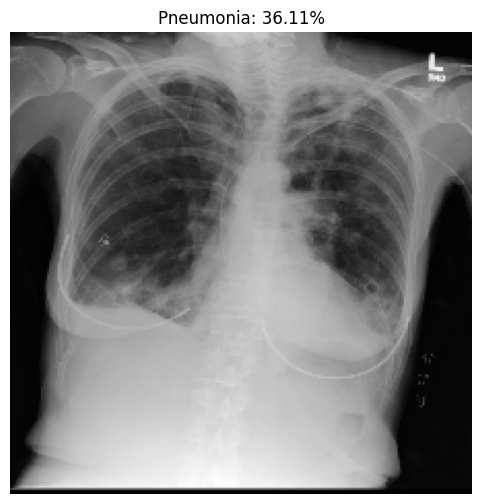

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(sample[:,:,0], cmap="gray")

plt.title(
    f"Pneumonia: {pred:.2%}"
)

plt.axis("off")

plt.show()